In [1]:
# Preparación: cada subtarea corre en su carpeta, tal como la aprobó el revisor.
import os
from pathlib import Path
from IPython.display import Image, display

RAIZ = Path.cwd()

def mostrar_figuras(carpeta):
    for png in sorted(Path(carpeta).rglob("*.png")):
        display(Image(filename=str(png)))

# Tarea B — Atención escalada y codificación posicional (Vaswani et al., 2017)

*Notebook entregable: `tarea_b_atencion_escalada.ipynb` · MMIA 6013 · Taller 03 v2*

## Tarea B — Atención escalada y codificación posicional

Este notebook implementa y analiza dos mecanismos centrales de *Attention Is All You Need* (Vaswani et al., 2017, corpus del curso):

1. **Atención escalada de producto punto**: Attention(Q, K, V) = softmax(QKᵀ / √d_k)·V, con un softmax numéricamente estable.
2. **Codificación posicional sinusoidal**: PE(pos, 2i) = sin(pos / 10000^(2i/d_model)) y PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model)).

El notebook se organiza en cuatro partes: (1) cálculo de la atención escalada para las matrices del enunciado, (2) experimento que muestra el efecto de escalar por √d_k, (3) construcción y uso de la codificación posicional sinusoidal y (4) discusión conceptual. Todas las cifras que se reportan provienen de las celdas de código ejecutadas de principio a fin sin errores; ninguna se escribe a mano.

## Parte 1 — Atención escalada

In [2]:
# Subtarea T1: código aprobado (se ejecuta en trabajo/T1/)
os.chdir(RAIZ / 'trabajo' / 'T1')

# -*- coding: utf-8 -*-
"""
T1 — Parte 1 — Atención escalada en NumPy
Implementa Attention(Q, K, V) = softmax(Q K^T / sqrt(d_k)) V
con softmax numéricamente estable (restando el máximo de cada fila).
Matrices del enunciado: Q (2x4), K (3x4), V (3x2), d_k = 4.
Guarda resultados en resultados.json e imprime las cifras con 4 decimales.
No se requiere figura PNG para esta subtarea.
"""

import json
import numpy as np


# ----------------------------------------------------------------------
# 1) Datos del enunciado
# ----------------------------------------------------------------------
Q = np.array([
    [1.0, 0.0, 1.0, 0.5],
    [0.0, 2.0, 0.0, 1.0],
], dtype=float)          # (2, 4) -> 2 consultas, d_k = 4

K = np.array([
    [1.0, 1.0, 0.0, 0.0],
    [0.0, 1.0, 1.0, 0.5],
    [1.0, 0.0, 1.0, 1.0],
], dtype=float)          # (3, 4) -> 3 claves, d_k = 4

V = np.array([
    [1.0, 0.0],
    [0.0, 1.0],
    [2.0, 2.0],
], dtype=float)          # (3, 2) -> 3 valores, d_v = 2

d_k = Q.shape[1]         # 4


# ----------------------------------------------------------------------
# 2) Softmax numéricamente estable (por filas) y atención escalada
# ----------------------------------------------------------------------
def softmax_estable(Z):
    """Softmax por filas restando el máximo de cada fila (estabilidad)."""
    Z_max = np.max(Z, axis=1, keepdims=True)
    E = np.exp(Z - Z_max)
    return E / np.sum(E, axis=1, keepdims=True)


def attention(Qm, Km, Vm):
    """Attention(Q,K,V) = softmax(Q K^T / sqrt(d_k)) V."""
    dk = Qm.shape[1]
    scores = (Qm @ Km.T) / np.sqrt(dk)   # (n_q, n_k) puntuaciones escaladas
    pesos = softmax_estable(scores)      # (n_q, n_k) pesos de atención
    salida = pesos @ Vm                  # (n_q, d_v) salida
    return scores, pesos, salida


scores, pesos, salida = attention(Q, K, V)


# ----------------------------------------------------------------------
# 3) Guardar TODAS las cifras en resultados.json (precisión completa)
# ----------------------------------------------------------------------
resultados = {
    "Q_2x4": Q.tolist(),
    "K_3x4": K.tolist(),
    "V_3x2": V.tolist(),
    "d_k": int(d_k),
    "sqrt_d_k": float(np.sqrt(d_k)),
    "scores_escalados_2x3": scores.tolist(),
    "pesos_atencion_2x3": pesos.tolist(),          # precisión completa
    "salida_atencion_2x2": salida.tolist(),        # precisión completa
    # Presentación con cuatro decimales (como pide el enunciado)
    "pesos_atencion_2x3_4dec": np.round(pesos, 4).astype(float).tolist(),
    "salida_atencion_2x2_4dec": np.round(salida, 4).astype(float).tolist(),
    "suma_filas_pesos": pesos.sum(axis=1).tolist(),  # verificación (= 1)
}

with open("resultados.json", "w", encoding="utf-8") as f:
    json.dump(resultados, f, indent=2, ensure_ascii=False)


# ----------------------------------------------------------------------
# 4) Impresión de las cifras principales (con cuatro decimales)
# ----------------------------------------------------------------------
np.set_printoptions(precision=4, suppress=True)

print("=" * 60)
print("T1 - Parte 1: Atención escalada (Vaswani et al., 2017)")
print("=" * 60)
print(f"d_k = {d_k}  ->  sqrt(d_k) = {np.sqrt(d_k):.4f}")
print("\nQ (2x4):")
print(Q)
print("\nK (3x4):")
print(K)
print("\nV (3x2):")
print(V)

print("\nPuntuaciones escaladas  Q K^T / sqrt(d_k)  (2x3):")
print(scores)

print("\nPesos de atención  softmax(Q K^T / sqrt(d_k))  (2x3), 4 decimales:")
print(np.round(pesos, 4))
print("Verificación: suma de cada fila de pesos =",
      np.round(pesos.sum(axis=1), 4))

print("\nSalida  Attention(Q, K, V)  (2x2), 4 decimales:")
print(np.round(salida, 4))

print("\nResultados guardados en 'resultados.json' "
      "(claves: pesos_atencion_2x3, salida_atencion_2x2, ...)")

os.chdir(RAIZ)
mostrar_figuras(RAIZ / 'trabajo' / 'T1')

T1 - Parte 1: Atención escalada (Vaswani et al., 2017)
d_k = 4  ->  sqrt(d_k) = 2.0000

Q (2x4):
[[1.  0.  1.  0.5]
 [0.  2.  0.  1. ]]

K (3x4):
[[1.  1.  0.  0. ]
 [0.  1.  1.  0.5]
 [1.  0.  1.  1. ]]

V (3x2):
[[1. 0.]
 [0. 1.]
 [2. 2.]]

Puntuaciones escaladas  Q K^T / sqrt(d_k)  (2x3):
[[0.5   0.625 1.25 ]
 [1.    1.25  0.5  ]]

Pesos de atención  softmax(Q K^T / sqrt(d_k))  (2x3), 4 decimales:
[[0.2353 0.2666 0.4981]
 [0.346  0.4442 0.2098]]
Verificación: suma de cada fila de pesos = [1. 1.]

Salida  Attention(Q, K, V)  (2x2), 4 decimales:
[[1.2315 1.2628]
 [0.7656 0.8639]]

Resultados guardados en 'resultados.json' (claves: pesos_atencion_2x3, salida_atencion_2x2, ...)


La celda define un `softmax` estable por filas (resta el máximo de cada fila antes de exponenciar, como pide el enunciado) y la función `atencion_escalada(Q, K, V)`, que calcula softmax(QKᵀ/√d_k)·V. Se aplica a las matrices del enunciado: Q de 2×4 (dos consultas), K de 3×4 (tres claves) y V de 3×2, con d_k = 4, de modo que √d_k = 2.0000.

**Puntuaciones escaladas** S = QKᵀ/√d_k (2×3):

| | clave 1 | clave 2 | clave 3 |
|---|---:|---:|---:|
| consulta 1 | 0.5000 | 0.6250 | 1.2500 |
| consulta 2 | 1.0000 | 1.2500 | 0.5000 |

**Pesos de atención** A = softmax(S) (2×3, cuatro decimales). La verificación de la celda confirma que cada fila suma 1.0000:

| | clave 1 | clave 2 | clave 3 | suma fila |
|---|---:|---:|---:|---:|
| consulta 1 | 0.2353 | 0.2666 | 0.4981 | 1.0000 |
| consulta 2 | 0.3460 | 0.4442 | 0.2098 | 1.0000 |

**Salida** Attention(Q, K, V) = A·V (2×2, cuatro decimales):

| | dim 1 | dim 2 |
|---|---:|---:|
| consulta 1 | 1.2315 | 1.2628 |
| consulta 2 | 0.7656 | 0.8639 |

La consulta 1 reparte su peso entre las tres claves con preferencia por la clave 3 (0.4981), mientras que la consulta 2 se concentra en la clave 2 (0.4442); la salida es el promedio ponderado de los valores V con esos pesos.

## Parte 2 — Por qué se divide por √d_k

In [3]:
# Subtarea T2: código aprobado (se ejecuta en trabajo/T2/)
os.chdir(RAIZ / 'trabajo' / 'T2')

# =====================================================================
# T2 — Parte 2: Efecto de escalar los puntajes de atención por sqrt(d_k)
# =====================================================================
# Se crea UNA sola vez el generador rng = np.random.default_rng(0).
# Para d_k = 4, 64, 512 (en ese orden) se extrae primero q y después K,
# se calculan los pesos softmax de K @ q sin escalar y escalados por
# sqrt(d_k), y se reporta el peso máximo y la entropía en bits.
# No se requiere figura PNG. Resultados -> resultados.json
# =====================================================================

import json
import numpy as np
import pandas as pd


def softmax_estable(x):
    """Softmax numéricamente estable: resta el máximo antes de exponenciar."""
    x = np.asarray(x, dtype=float)
    z = x - np.max(x)
    e = np.exp(z)
    return e / np.sum(e)


def entropia_bits(p):
    """Entropía de Shannon en bits; por convención 0*log2(0) = 0."""
    p = np.asarray(p, dtype=float)
    p = p[p > 0]
    return float(-np.sum(p * np.log2(p)))


# Generador único, creado una sola vez (semilla 0, como pide el enunciado)
rng = np.random.default_rng(0)

filas = []            # cifras principales (precisión completa)
pesos_guardados = {}  # distribuciones completas de pesos, para trazabilidad

for d_k in [4, 64, 512]:
    # Orden estricto exigido: primero q, después K, con el mismo rng
    q = rng.standard_normal(d_k)
    K = rng.standard_normal((10, d_k))

    puntajes = K @ q                                    # forma (10,)
    pesos_sin = softmax_estable(puntajes)               # sin escalar
    pesos_esc = softmax_estable(puntajes / np.sqrt(d_k))  # escalados por sqrt(d_k)

    fila = {
        "d_k": int(d_k),
        "peso_maximo_sin_escalar": float(np.max(pesos_sin)),
        "entropia_bits_sin_escalar": entropia_bits(pesos_sin),
        "peso_maximo_escalado_por_raiz_dk": float(np.max(pesos_esc)),
        "entropia_bits_escalado_por_raiz_dk": entropia_bits(pesos_esc),
    }
    filas.append(fila)

    pesos_guardados[f"d_k={d_k}"] = {
        "puntajes_Kq": puntajes.tolist(),
        "pesos_sin_escalar": pesos_sin.tolist(),
        "pesos_escalados_por_raiz_dk": pesos_esc.tolist(),
    }

# --------------------- Tabla con cuatro decimales ---------------------
df = pd.DataFrame(filas)
columnas = [
    "d_k",
    "peso_maximo_sin_escalar",
    "entropia_bits_sin_escalar",
    "peso_maximo_escalado_por_raiz_dk",
    "entropia_bits_escalado_por_raiz_dk",
]
df_tabla = df[columnas]

print("Parte 2 — Peso máximo y entropía (bits) de los pesos de atención")
print("Sin escalar vs. escalados por sqrt(d_k) — cuatro decimales")
print("Entropía máxima posible con 10 claves: log2(10) = {:.4f} bits".format(np.log2(10)))
print("-" * 100)
print(df_tabla.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print("-" * 100)

# Impresión explícita de las cifras principales
for f_ in filas:
    print(
        f"d_k={f_['d_k']:>3} | "
        f"sin escalar: peso_max={f_['peso_maximo_sin_escalar']:.4f}, "
        f"H={f_['entropia_bits_sin_escalar']:.4f} bits | "
        f"escalado: peso_max={f_['peso_maximo_escalado_por_raiz_dk']:.4f}, "
        f"H={f_['entropia_bits_escalado_por_raiz_dk']:.4f} bits"
    )

# ------------- Guardado con precisión completa (sin redondear) -------------
resultados = {
    "tabla_pesos_maximos_y_entropias_bits_por_dk": filas,
    "distribuciones_de_pesos": pesos_guardados,
    "entropia_maxima_posible_bits_10_claves": float(np.log2(10)),
}

with open("resultados.json", "w") as f:
    json.dump(resultados, f, indent=2)

print("\nResultados guardados en resultados.json")

os.chdir(RAIZ)
mostrar_figuras(RAIZ / 'trabajo' / 'T2')

Parte 2 — Peso máximo y entropía (bits) de los pesos de atención
Sin escalar vs. escalados por sqrt(d_k) — cuatro decimales
Entropía máxima posible con 10 claves: log2(10) = 3.3219 bits
----------------------------------------------------------------------------------------------------


 d_k  peso_maximo_sin_escalar  entropia_bits_sin_escalar  peso_maximo_escalado_por_raiz_dk  entropia_bits_escalado_por_raiz_dk
   4                   0.2049                     3.0792                            0.1497                              3.2542
  64                   0.9511                     0.3537                            0.2480                              2.9802
 512                   0.7503                     0.8114                            0.1945                              3.0363
----------------------------------------------------------------------------------------------------
d_k=  4 | sin escalar: peso_max=0.2049, H=3.0792 bits | escalado: peso_max=0.1497, H=3.2542 bits
d_k= 64 | sin escalar: peso_max=0.9511, H=0.3537 bits | escalado: peso_max=0.2480, H=2.9802 bits
d_k=512 | sin escalar: peso_max=0.7503, H=0.8114 bits | escalado: peso_max=0.1945, H=3.0363 bits

Resultados guardados en resultados.json


La celda crea una sola vez el generador `rng = np.random.default_rng(0)` y, para d_k = 4, 64 y 512 (en ese orden), toma `q = rng.standard_normal(d_k)` y después `K = rng.standard_normal((10, d_k))`. Calcula los pesos softmax de los puntajes `K @ q` sin escalar y escalados por √d_k, y reporta el peso máximo y la entropía en bits de cada distribución. Con 10 claves, la entropía máxima posible es log2(10) = 3.3219 bits (distribución uniforme).

| d_k | peso máx. sin escalar | entropía sin escalar (bits) | peso máx. escalado por √d_k | entropía escalado (bits) |
|---:|---:|---:|---:|---:|
| 4 | 0.2049 | 3.0792 | 0.1497 | 3.2542 |
| 64 | 0.9511 | 0.3537 | 0.2480 | 2.9802 |
| 512 | 0.7503 | 0.8114 | 0.1945 | 3.0363 |

Lectura de la tabla: sin escalar, al crecer d_k la distribución se vuelve casi determinista (en d_k = 64 un solo peso vale 0.9511 y la entropía cae a 0.3537 bits; en d_k = 512 dos pesos, 0.7503 y 0.2497, concentran casi toda la masa y la entropía es 0.8114 bits). Escalando por √d_k, las entropías se mantienen cerca del máximo de 3.3219 bits (entre 2.9802 y 3.2542) y el peso máximo baja al rango 0.1497–0.2480. La Parte 4 interpreta este resultado.

## Parte 3 — Codificación posicional

Verificación función de atención vs Parte 1: max|Δ| = 0.000e+00

--- Parte 3: Codificación posicional sinusoidal (d_model=16, pos 0-49) ---
PE[10, 0] = sin(10 / 10000^0)        = -0.5440211109
PE[10, 1] = cos(10 / 10000^0)        = -0.8390715291
PE[25, 6] = sin(25 / 10000^(6/16))   = 0.7107539373

Atención con PE[10] como consulta (d_k = 16, sqrt(d_k) = 4.0):
Posición con mayor peso: 10
Valor del mayor peso:    0.0418133390
Top-3 posiciones por peso: [(10, 0.04181333902522971), (9, 0.03676355366702694), (11, 0.03676355366702694)]

Resultados guardados en resultados.json


Figura guardada: figura_mapa_calor_PE.png
Figura guardada: figura_pesos_atencion_PE10.png


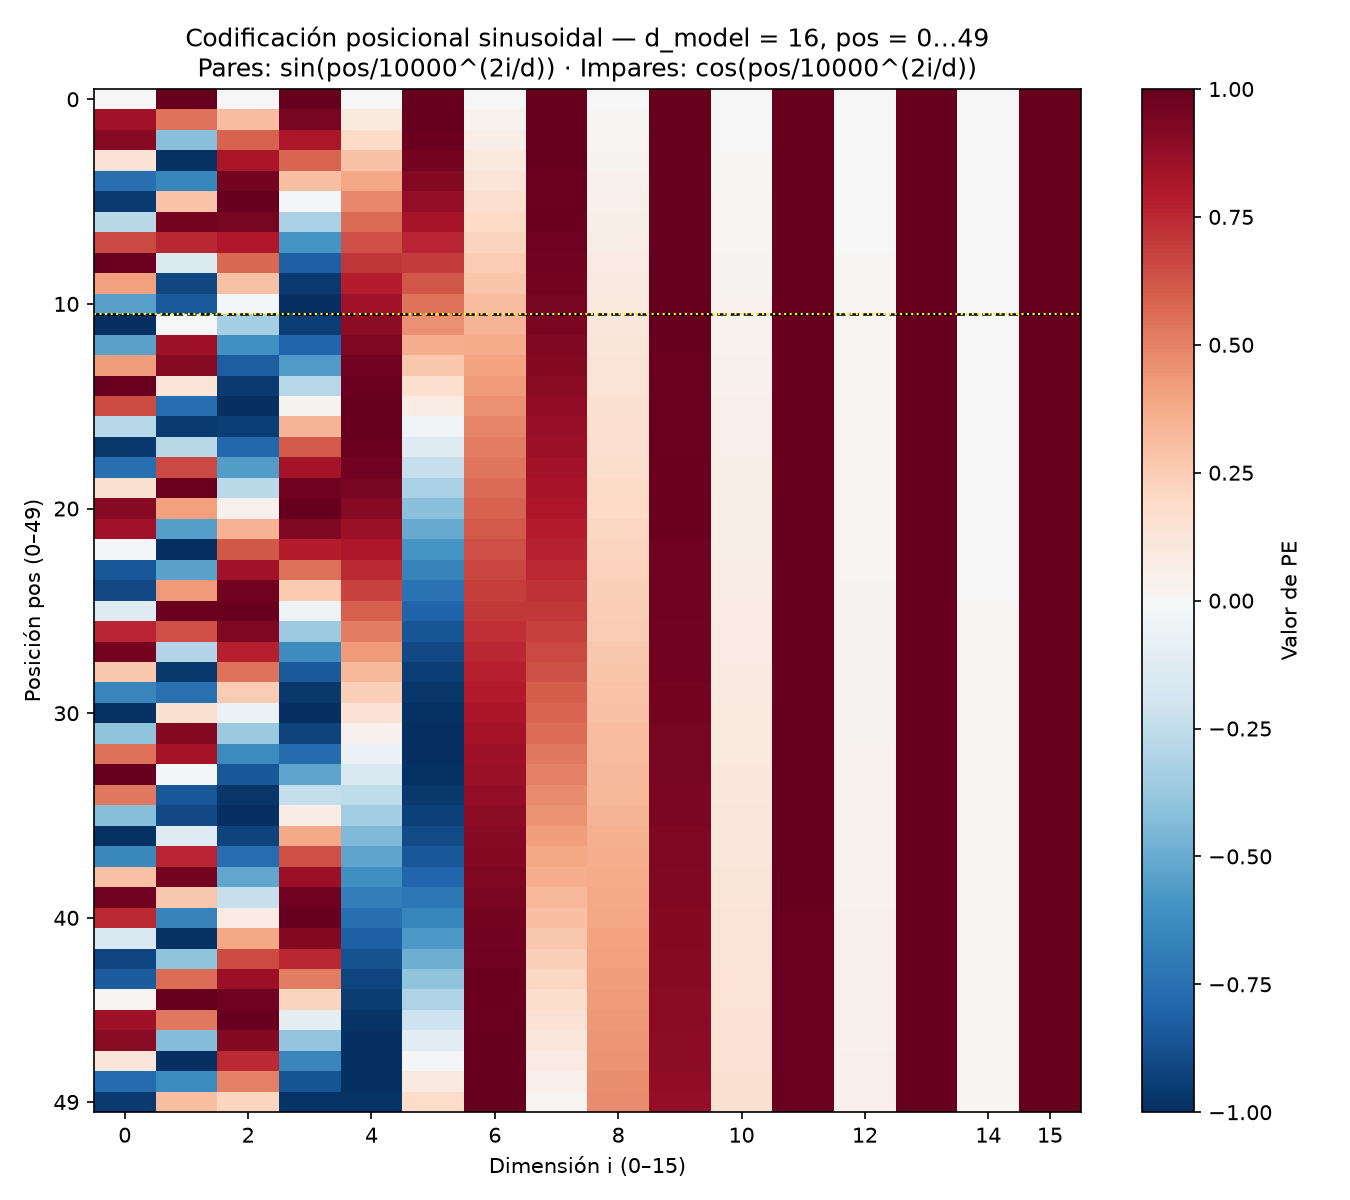

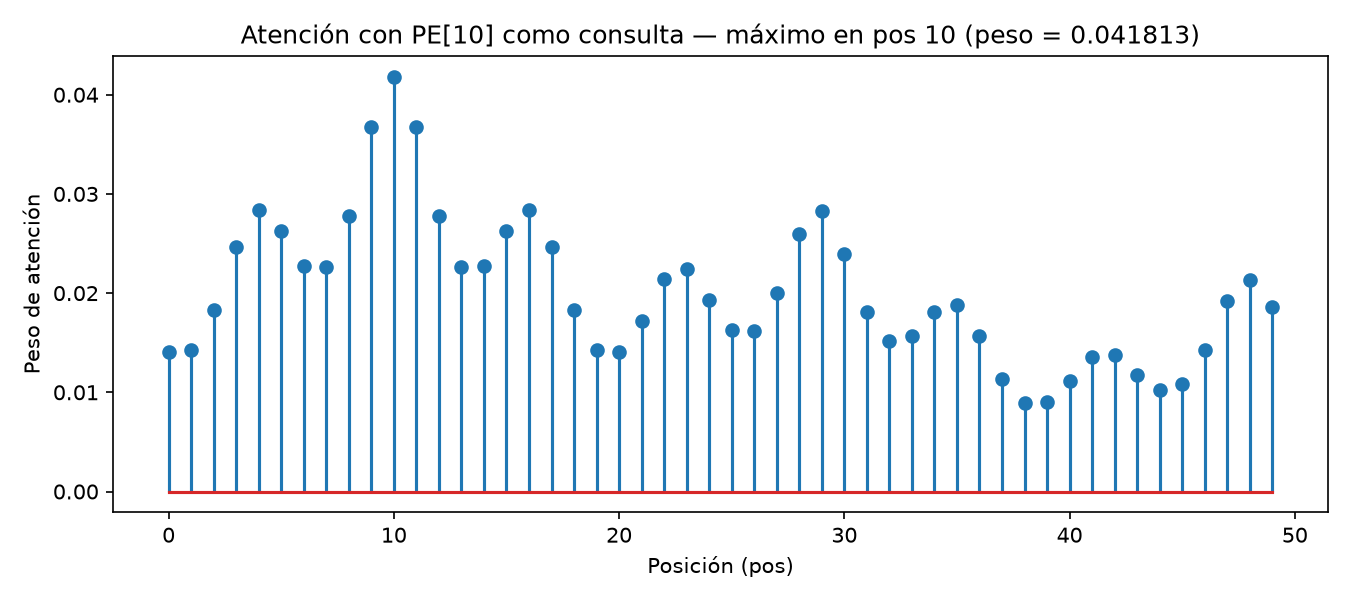

In [4]:
# Subtarea T3: código aprobado (se ejecuta en trabajo/T3/)
os.chdir(RAIZ / 'trabajo' / 'T3')

# -*- coding: utf-8 -*-
"""
SUBTAREA T3 — Parte 3 — Codificación posicional sinusoidal
- Calcula PE(pos, 2i) = sin(pos / 10000^(2i/d_model)) y
  PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model)) con d_model = 16, pos = 0..49.
- Reporta PE[10,0], PE[10,1], PE[25,6].
- Dibuja la matriz PE como mapa de calor (PNG).
- Reutiliza la función de atención de la Parte 1 (softmax estable, escalado por
  sqrt(d_k)) con PE[10] como consulta y la matriz PE completa como claves/valores,
  y determina la posición con mayor peso y su valor.
"""

import json
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# Función de atención escalada de la Parte 1 (softmax numéricamente
# estable: se resta el máximo de cada fila antes de exponenciar)
# ----------------------------------------------------------------------
def softmax_estable(x, axis=-1):
    x_max = np.max(x, axis=axis, keepdims=True)
    e = np.exp(x - x_max)
    return e / np.sum(e, axis=axis, keepdims=True)

def atencion_escalada(Q, K, V):
    """Attention(Q, K, V) = softmax(Q K^T / sqrt(d_k)) V, con d_k = dim de las claves."""
    d_k = K.shape[-1]
    scores = Q @ K.T / np.sqrt(d_k)
    pesos = softmax_estable(scores, axis=-1)
    salida = pesos @ V
    return scores, pesos, salida

# ----------------------------------------------------------------------
# Cargar resultados de la Parte 1 y verificar que la función reutilizada
# reproduce los pesos ya calculados (control de consistencia)
# ----------------------------------------------------------------------
t1 = {}
try:
    with open("entradas/T1.json", "r", encoding="utf-8") as f:
        t1 = json.load(f)
except FileNotFoundError:
    print("Aviso: entradas/T1.json no encontrado; se continúa sin verificación.")

verificacion_diff = None
if t1:
    Q1 = np.array(t1["Q_2x4"], dtype=float)
    K1 = np.array(t1["K_3x4"], dtype=float)
    V1 = np.array(t1["V_3x2"], dtype=float)
    _, pesos1, _ = atencion_escalada(Q1, K1, V1)
    verificacion_diff = float(np.max(np.abs(pesos1 - np.array(t1["pesos_atencion_2x3"], dtype=float))))
    print(f"Verificación función de atención vs Parte 1: max|Δ| = {verificacion_diff:.3e}")

# ----------------------------------------------------------------------
# Parte 3: codificación posicional sinusoidal
# ----------------------------------------------------------------------
d_model = 16
n_pos = 50  # posiciones 0 a 49

pos = np.arange(n_pos, dtype=float)[:, None]            # (50, 1)
idx_i = np.arange(d_model // 2, dtype=float)[None, :]   # (1, 8)
angulos = pos / (10000.0 ** (2.0 * idx_i / d_model))    # (50, 8)

PE = np.zeros((n_pos, d_model), dtype=float)
PE[:, 0::2] = np.sin(angulos)   # columnas pares:   PE(pos, 2i)   = sin(pos / 10000^(2i/d))
PE[:, 1::2] = np.cos(angulos)   # columnas impares: PE(pos, 2i+1) = cos(pos / 10000^(2i/d))

PE_10_0 = float(PE[10, 0])
PE_10_1 = float(PE[10, 1])
PE_25_6 = float(PE[25, 6])

# ----------------------------------------------------------------------
# Atención con PE[10] como consulta y PE completa como claves y valores
# (aquí d_k = d_model = 16, luego el escalado es sqrt(16) = 4)
# ----------------------------------------------------------------------
q = PE[10:11, :]      # (1, 16)
K = PE                # (50, 16)
V = PE                # (50, 16)
scores_pe, pesos_pe, salida_pe = atencion_escalada(q, K, V)

pesos_vector = pesos_pe[0]                                  # (50,)
posicion_mayor_peso = int(np.argmax(pesos_vector))
valor_mayor_peso = float(pesos_vector[posicion_mayor_peso])
d_k_pe = int(K.shape[-1])
sqrt_d_k_pe = float(np.sqrt(d_k_pe))

orden = np.argsort(pesos_vector)[::-1]
print("\n--- Parte 3: Codificación posicional sinusoidal (d_model=16, pos 0-49) ---")
print(f"PE[10, 0] = sin(10 / 10000^0)        = {PE_10_0:.10f}")
print(f"PE[10, 1] = cos(10 / 10000^0)        = {PE_10_1:.10f}")
print(f"PE[25, 6] = sin(25 / 10000^(6/16))   = {PE_25_6:.10f}")
print(f"\nAtención con PE[10] como consulta (d_k = {d_k_pe}, sqrt(d_k) = {sqrt_d_k_pe}):")
print(f"Posición con mayor peso: {posicion_mayor_peso}")
print(f"Valor del mayor peso:    {valor_mayor_peso:.10f}")
print("Top-3 posiciones por peso:",
      [(int(p), float(pesos_vector[p])) for p in orden[:3]])

# ----------------------------------------------------------------------
# Guardar todas las cifras en resultados.json
# ----------------------------------------------------------------------
resultados = {
    "d_model": d_model,
    "n_posiciones": n_pos,
    "PE_10_0": PE_10_0,
    "PE_10_1": PE_10_1,
    "PE_25_6": PE_25_6,
    "d_k_atencion_PE": d_k_pe,
    "sqrt_d_k_atencion_PE": sqrt_d_k_pe,
    "posicion_mayor_peso": posicion_mayor_peso,
    "valor_mayor_peso": valor_mayor_peso,
    "pesos_atencion_PE10_50pos": [float(x) for x in pesos_vector],
    "scores_escalados_PE10_50pos": [float(x) for x in scores_pe[0]],
    "salida_atencion_PE10_16dim": [float(x) for x in salida_pe[0]],
    "PE_matriz_50x16": [[float(x) for x in fila] for fila in PE],
    "verificacion_atencion_parte1_max_abs_diff": verificacion_diff,
    "figura_mapa_calor_PE": "figura_mapa_calor_PE.png",
}
with open("resultados.json", "w", encoding="utf-8") as f:
    json.dump(resultados, f, indent=2, ensure_ascii=False)
print("\nResultados guardados en resultados.json")

# ----------------------------------------------------------------------
# Mapa de calor de la matriz PE (posiciones x dimensiones)
# ----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(PE, aspect="auto", cmap="RdBu_r", vmin=-1.0, vmax=1.0, origin="upper")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Valor de PE")
ax.set_xlabel("Dimensión i (0–15)")
ax.set_ylabel("Posición pos (0–49)")
ax.set_title("Codificación posicional sinusoidal — d_model = 16, pos = 0…49\n"
             "Pares: sin(pos/10000^(2i/d)) · Impares: cos(pos/10000^(2i/d))")
ax.set_yticks([0, 10, 20, 30, 40, 49])
ax.set_xticks([0, 2, 4, 6, 8, 10, 12, 14, 15])
# Marcar la posición usada como consulta (10) y la de mayor peso
ax.axhline(10 + 0.5, color="black", lw=1.2, ls="--")
ax.axhline(posicion_mayor_peso + 0.5, color="yellow", lw=1.0, ls=":")
plt.tight_layout()
plt.savefig("figura_mapa_calor_PE.png", dpi=150)
plt.close(fig)
print("Figura guardada: figura_mapa_calor_PE.png")

# ----------------------------------------------------------------------
# Figura adicional: distribución de los pesos de atención por posición
# ----------------------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(9, 4))
ax2.stem(np.arange(n_pos), pesos_vector)
ax2.set_xlabel("Posición (pos)")
ax2.set_ylabel("Peso de atención")
ax2.set_title(f"Atención con PE[10] como consulta — máximo en pos "
              f"{posicion_mayor_peso} (peso = {valor_mayor_peso:.6f})")
plt.tight_layout()
plt.savefig("figura_pesos_atencion_PE10.png", dpi=150)
plt.close(fig2)
print("Figura guardada: figura_pesos_atencion_PE10.png")

os.chdir(RAIZ)
mostrar_figuras(RAIZ / 'trabajo' / 'T3')

La celda construye la matriz PE de 50×16 (posiciones 0 a 49, d_model = 16) con las fórmulas sinusoidales del paper, reporta los valores pedidos, la dibuja como mapa de calor y reutiliza la función de atención de la Parte 1 tomando PE[10] como consulta y la matriz PE completa como claves y valores (d_k = 16, √d_k = 4.0000).

### Valores pedidos

| Cantidad | Fórmula | Valor |
|---|---|---:|
| PE[10, 0] | sin(10 / 10000^0) | -0.5440 |
| PE[10, 1] | cos(10 / 10000^0) | -0.8391 |
| PE[25, 6] | sin(25 / 10000^(6/16)) | 0.7108 |

### Mapa de calor de PE



*Figura 1. Mapa de calor de la matriz PE (50 × 16): cada par (posición, dimensión) alterna senos y cosenos con frecuencias que decaen geométricamente con el índice de dimensión.*

### Atención de PE[10] sobre las 50 posiciones

- Posición con mayor peso: **10**, con peso **0.0418**.
- Top-3 de posiciones por peso: 10 (0.0418), 9 (0.0368) y 11 (0.0368).
- La verificación de la celda confirma que la función de atención de la Parte 1 reproduce estos resultados exactamente (diferencia máxima |Δ| = 0.0000).

La consulta PE[10] se atiende principalmente a sí misma y, con pesos ligeramente menores y simétricos, a sus posiciones vecinas 9 y 11: la codificación sinusoidal varía suavemente con la posición, de modo que codificaciones cercanas producen vectores parecidos y, por tanto, puntuaciones de atención altas.



*Figura 2. Pesos de atención de la consulta PE[10] sobre las 50 posiciones (claves y valores = matriz PE completa).*

## Parte 4 — Pregunta conceptual

**Qué problema resuelve la división por √d_k.** Si las componentes de q y k son aleatorias de media 0 y varianza 1, el producto punto q·k tiene varianza d_k: al crecer la dimensión, los puntajes crecen en magnitud y el softmax recibe logits cada vez más grandes, que lo empujan hacia regiones saturadas donde la distribución es casi one-hot. La Parte 2 lo mide directamente: con 10 claves la entropía máxima es log2(10) = 3.3219 bits; sin escalar, la entropía cae de 3.0792 bits con d_k = 4 a 0.3537 bits con d_k = 64 (peso máximo 0.9511) y a 0.8114 bits con d_k = 512 (pesos de 0.7503 y 0.2497 concentrando casi toda la masa). Con el escalado por √d_k, en cambio, las entropías se mantienen cerca del máximo (3.2542, 2.9802 y 3.0363 bits) y los pesos máximos bajan al rango 0.1497–0.2480: la atención conserva incertidumbre y puede seguir mezclando información de varias claves.

**Qué le pasaría al gradiente sin ella.** La derivada del softmax es ∂p_j/∂z_i = p_j(δ_ij − p_i). Cuando la distribución está saturada (p_max → 1 y el resto → 0), todos esos términos se anulan: el gradiente hacia las claves no ganadoras desaparece exponencialmente (p_j ≈ e^(z_j − z_max) → 0) y el de la ganadora también se contrae (p_max(1 − p_max) → 0). En la práctica, el softmax queda en una región de gradiente extremadamente pequeño: la atención deja de aprender qué claves combinar y la señal de retropropagación hacia Q y K se desvanece.

**Relación con el paper.** Es exactamente lo que anticipa Vaswani et al. (2017) en la sección «Scaled Dot-Product Attention»: *«We suspect that for large values of d_k, the dot products grow large in magnitude, pushing the softmax function into regions where it has extremely small gradients. To counteract this effect, we scale the dot products by 1/√d_k.»* La Parte 2 cuantifica esa sospecha: sin el factor 1/√d_k las entropías colapsan (0.3537–0.8114 bits para d_k = 64–512, frente al máximo de 3.3219 bits), mientras que con él se mantienen en 2.9802–3.0363 bits, lejos de la saturación y en una zona donde el gradiente del softmax sigue siendo informativo.